# Google AI Overview Analysis: US vs. Nigeria
### Pre-processing, Exploration, and Classification

## 1. Imports & Setup

In [1]:
import ast
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

## 2. Data Loading & Pre-processing

In [2]:
FILES = {
    ('obgyn',       'Nigeria'):       'obgyn_nigeria.csv',
    ('obgyn',       'United States'): 'obgyn_scrape.csv',
    ('primarycare', 'Nigeria'):       'primarycare_nigeria.csv',
    ('primarycare', 'United States'): 'primarycare_scrape.csv',
    ('psych',       'Nigeria'):       'psych_nigeria.csv',
    ('psych',       'United States'): 'psych_scrape.csv',
}

frames = []
for (specialty, location), fname in FILES.items():
    df = pd.read_csv(fname)
    df['specialty'] = specialty
    df['location']  = location
    frames.append(df)

df = pd.concat(frames, ignore_index=True)

# Normalise has_ai_overview to bool
df['has_ai_overview'] = df['has_ai_overview'].astype(str).str.strip().str.lower() == 'true'

# Parse list/dict columns stored as Python literals
def safe_eval(val):
    try:
        return ast.literal_eval(str(val))
    except Exception:
        return []

for col in ['all_items', 'cited_sources', 'all_references', 'paa_questions']:
    if col in df.columns:
        df[col] = df[col].apply(safe_eval)

# Derived features
df['query_word_count']    = df['query'].str.split().str.len()
df['n_cited_sources']     = df['cited_sources'].apply(len)
df['n_all_references']    = df['all_references'].apply(len)
df['n_paa']               = df['paa_questions'].apply(len)
df['n_ai_bullets']        = df['all_items'].apply(len)

print(f'Total rows: {len(df)}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Total rows: 316
Columns: ['location', 'query', 'has_ai_overview', 'all_items', 'cited_sources', 'all_references', 'paa_questions', 'specialty', 'all_content', 'query_word_count', 'n_cited_sources', 'n_all_references', 'n_paa', 'n_ai_bullets']


,location,query,has_ai_overview,all_items,cited_sources,all_references,paa_questions,specialty,all_content,query_word_count,n_cited_sources,n_all_references,n_paa,n_ai_bullets
0,Nigeria,early signs of pregnancy,True,"[Missed Period: The most common indicator, tho...",[{'title': '18 Early Symptoms of Pregnancy: Ho...,[{'title': '18 Early Symptoms of Pregnancy: Ho...,"[What are the first signs of pregnancy?, How d...",obgyn,NaN,4,8,8,4,7
1,Nigeria,what are the symptoms of pregnancy,True,"[Missed Period: Usually the most common sign, ...",[{'title': '18 Early Symptoms of Pregnancy: Ho...,[{'title': '18 Early Symptoms of Pregnancy: Ho...,"[How do I know I am pregnant without a test?, ...",obgyn,NaN,6,11,12,4,12
2,Nigeria,how early can you take a pregnancy test,True,"[Best Time: The day after your missed period.,...",[{'title': 'Calculate When to Take a Pregnancy...,"[{'title': 'Doing a pregnancy test - NHS', 'li...",[What is the earliest a pregnancy test will sh...,obgyn,NaN,8,9,9,4,4


## 3. Exploration — A: AI Overview Presence Rate (US vs. Nigeria)

  specialty      location     rate  n_with_ai  n_total  rate_pct
      obgyn       Nigeria 0.907407         49       54      90.7
      obgyn United States 0.888889         48       54      88.9
primarycare       Nigeria 0.942308         49       52      94.2
primarycare United States 0.884615         46       52      88.5
      psych       Nigeria 0.865385         45       52      86.5
      psych United States 0.865385         45       52      86.5


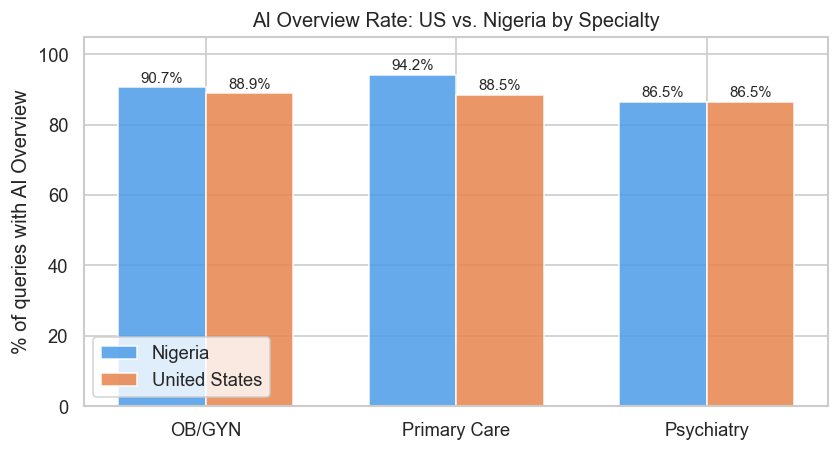

In [3]:
# Proportion of queries that triggered an AI overview
ai_rate = (
    df.groupby(['specialty', 'location'])['has_ai_overview']
    .agg(['mean', 'sum', 'count'])
    .rename(columns={'mean': 'rate', 'sum': 'n_with_ai', 'count': 'n_total'})
    .reset_index()
)
ai_rate['rate_pct'] = (ai_rate['rate'] * 100).round(1)
print(ai_rate.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(ai_rate['specialty'].unique()))
specialties = ai_rate['specialty'].unique()
width = 0.35
colors = {'Nigeria': '#4C9BE8', 'United States': '#E8844C'}

for i, loc in enumerate(['Nigeria', 'United States']):
    subset = ai_rate[ai_rate['location'] == loc].set_index('specialty').reindex(specialties)
    bars = ax.bar(x + i * width - width/2, subset['rate_pct'], width, label=loc, color=colors[loc], alpha=0.85)
    for bar, val in zip(bars, subset['rate_pct']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val}%',
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(['OB/GYN', 'Primary Care', 'Psychiatry'])
ax.set_ylabel('% of queries with AI Overview')
ax.set_title('AI Overview Rate: US vs. Nigeria by Specialty')
ax.legend()
ax.set_ylim(0, 105)
plt.show()


## 4. Exploration — B: Source Type Analysis (Medical vs. Layman)

location               Nigeria  United States
source_type                                  
Authoritative Medical     31.8           24.9
Consumer Health            6.8            6.3
Layman / Social           14.5           15.2
Other                     46.9           53.6


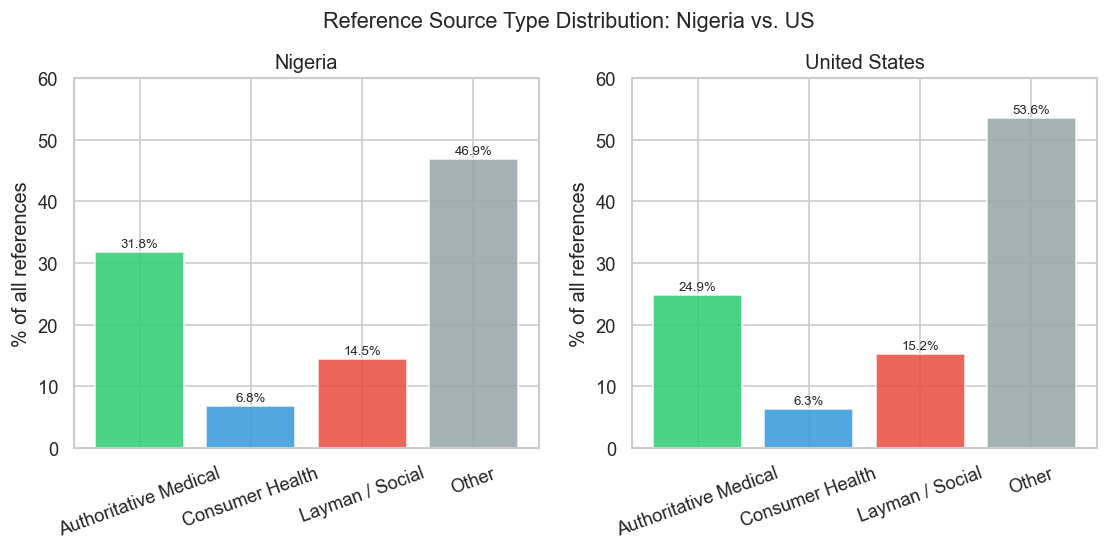

In [4]:
# Classify each source domain into a tier
AUTHORITATIVE = {
    'Mayo Clinic', 'Cleveland Clinic', 'Johns Hopkins Medicine', 'NHS',
    'nhs.uk', 'National Institutes of Health (.gov)', 'MedlinePlus (.gov)',
    'Centers for Disease Control and Prevention | CDC (.gov)', 'CDC',
    'World Health Organization (WHO)', 'ACOG', 'Yale Medicine',
    'UCLA Health', 'UPMC', 'NewYork-Presbyterian', 'Stanford Medicine',
    'Harvard Health Publishing', 'American Heart Association',
    'American Diabetes Association', 'National Alliance on Mental Illness',
}
CONSUMER_HEALTH = {
    'WebMD', 'Healthline', 'Medical News Today', 'Verywell Health',
    'Verywell Mind', 'Verywell Family', 'Healthgrades', 'Everyday Health',
    'MedPark Hospital', 'Planned Parenthood',
}
LAYMAN = {
    'YouTube', 'Reddit', 'Wikipedia', 'TikTok', 'Quora',
    'BabyCenter', 'What to Expect', 'Mumsnet',
}

def classify_source(source_name):
    if source_name in AUTHORITATIVE:
        return 'Authoritative Medical'
    elif source_name in CONSUMER_HEALTH:
        return 'Consumer Health'
    elif source_name in LAYMAN:
        return 'Layman / Social'
    else:
        return 'Other'

# Explode all_references into one row per source
ref_rows = []
for _, row in df.iterrows():
    for ref in row['all_references']:
        ref_rows.append({
            'specialty': row['specialty'],
            'location':  row['location'],
            'source':    ref.get('source', ''),
            'source_type': classify_source(ref.get('source', '')),
        })

refs = pd.DataFrame(ref_rows)

# Share of each source type by location
src_share = (
    refs.groupby(['location', 'source_type'])
    .size()
    .reset_index(name='count')
)
src_share['pct'] = src_share.groupby('location')['count'].transform(lambda x: x / x.sum() * 100)

print(src_share.pivot(index='source_type', columns='location', values='pct').round(1))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
type_order = ['Authoritative Medical', 'Consumer Health', 'Layman / Social', 'Other']
palette = {'Authoritative Medical': '#2ecc71', 'Consumer Health': '#3498db',
           'Layman / Social': '#e74c3c', 'Other': '#95a5a6'}

for ax, loc in zip(axes, ['Nigeria', 'United States']):
    sub = src_share[src_share['location'] == loc].set_index('source_type').reindex(type_order)
    bars = ax.bar(sub.index, sub['pct'], color=[palette[t] for t in type_order], alpha=0.85)
    for bar, val in zip(bars, sub['pct'].fillna(0)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%',
                ha='center', va='bottom', fontsize=8)
    ax.set_title(loc)
    ax.set_ylabel('% of all references')
    ax.set_ylim(0, 60)
    ax.tick_params(axis='x', rotation=20)

fig.suptitle('Reference Source Type Distribution: Nigeria vs. US', fontsize=13, y=1.02)
plt.show()

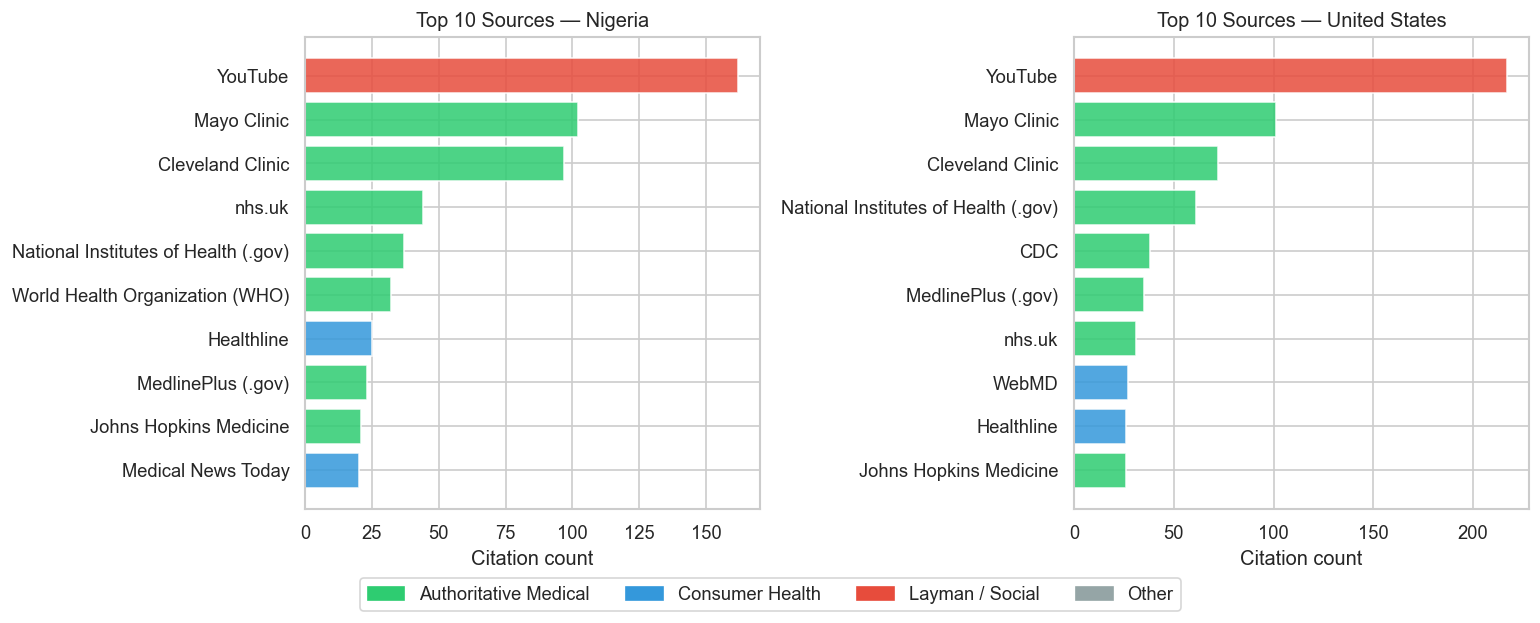

In [5]:
# Top 10 most-cited sources by location
top_sources = (
    refs.groupby(['location', 'source'])
    .size()
    .reset_index(name='count')
    .sort_values(['location', 'count'], ascending=[True, False])
)

top_sources['source'] = top_sources['source'].replace(
    'Centers for Disease Control and Prevention | CDC (.gov)',
    'CDC'
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, loc in zip(axes, ['Nigeria', 'United States']):
    sub = top_sources[top_sources['location'] == loc].head(10)
    colors_bar = [palette[classify_source(s)] for s in sub['source']]
    ax.barh(sub['source'][::-1], sub['count'][::-1], color=colors_bar[::-1], alpha=0.85)
    ax.set_title(f'Top 10 Sources — {loc}')
    ax.set_xlabel('Citation count')

# Legend
from matplotlib.patches import Patch
handles = [Patch(color=c, label=t) for t, c in palette.items()]
fig.legend(handles=handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

## 5. Exploration — C: Sentiment of AI Overview Text (US vs. Nigeria)

                            mean  median    std
specialty   location                           
obgyn       Nigeria       -0.054  -0.071  0.158
            United States -0.013  -0.004  0.189
primarycare Nigeria       -0.132  -0.116  0.200
            United States -0.117  -0.109  0.163
psych       Nigeria       -0.211  -0.203  0.261
            United States -0.156  -0.138  0.235


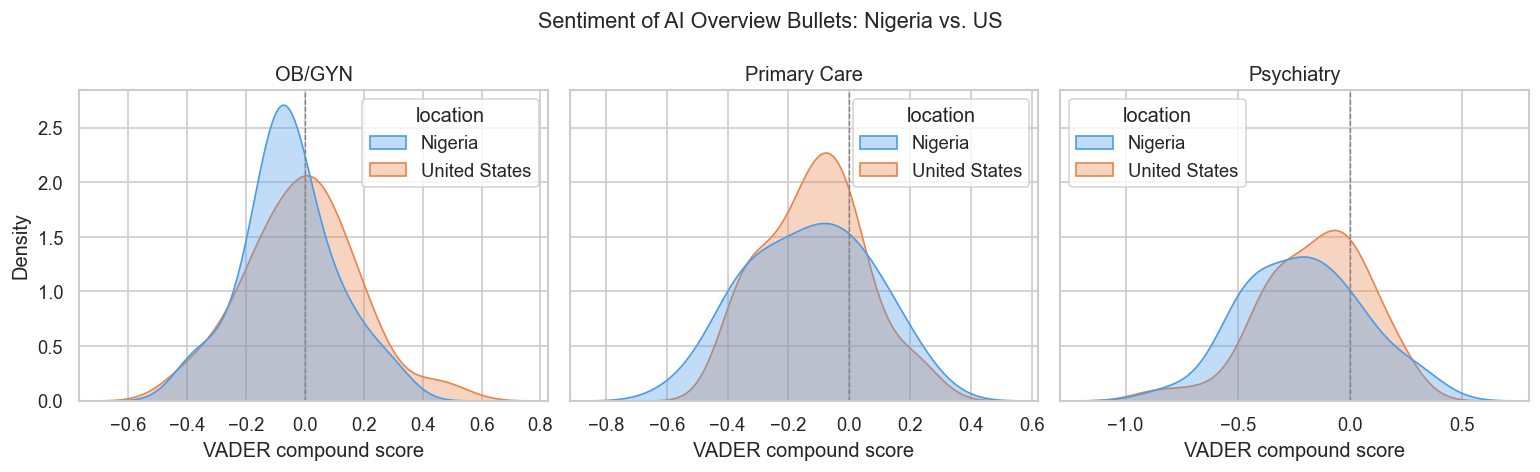

In [6]:
sia = SentimentIntensityAnalyzer()

def sentiment_of_bullets(bullet_list):
    """Average compound VADER score across all bullet points."""
    if not bullet_list:
        return np.nan
    scores = [sia.polarity_scores(str(b))['compound'] for b in bullet_list]
    return np.mean(scores)

ai_df = df[df['has_ai_overview']].copy()
ai_df['sentiment'] = ai_df['all_items'].apply(sentiment_of_bullets)

sent_summary = (
    ai_df.groupby(['specialty', 'location'])['sentiment']
    .agg(['mean', 'median', 'std'])
    .round(3)
)
print(sent_summary)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
spec_labels = {'obgyn': 'OB/GYN', 'primarycare': 'Primary Care', 'psych': 'Psychiatry'}
for ax, spec in zip(axes, ['obgyn', 'primarycare', 'psych']):
    sub = ai_df[ai_df['specialty'] == spec]
    sns.kdeplot(data=sub, x='sentiment', hue='location', ax=ax,
                palette=colors, fill=True, alpha=0.35, common_norm=False)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(spec_labels[spec])
    ax.set_xlabel('VADER compound score')

axes[0].set_ylabel('Density')
fig.suptitle('Sentiment of AI Overview Bullets: Nigeria vs. US', fontsize=13)
plt.tight_layout()
plt.show()

/var/folders/sv/npgjbzfj0bq839mrmmpygqvr0000gn/T/ipykernel_31159/3073033608.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['OB/GYN', 'Primary Care', 'Psychiatry'])


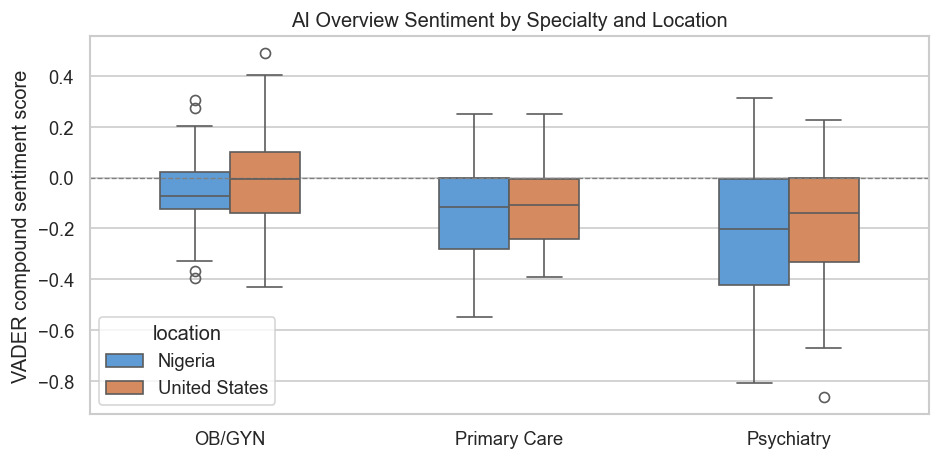

In [7]:
# Box plot for overall comparison
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=ai_df, x='specialty', y='sentiment', hue='location',
            palette=colors, width=0.5, ax=ax)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xticklabels(['OB/GYN', 'Primary Care', 'Psychiatry'])
ax.set_xlabel('')
ax.set_ylabel('VADER compound sentiment score')
ax.set_title('AI Overview Sentiment by Specialty and Location')
plt.tight_layout()
plt.show()

## 6. Classification — Predicting AI Overview Presence

We use **logistic regression** to predict whether a query will trigger an AI overview, using:
- Location (Nigeria / US)
- Specialty (OB/GYN, Primary Care, Psychiatry)
- Query word count
- Number of PAA (People Also Ask) questions returned
- Number of total references returned

In [8]:
le_loc  = LabelEncoder()
le_spec = LabelEncoder()

clf_df = df.copy()
clf_df['location_enc']  = le_loc.fit_transform(clf_df['location'])
clf_df['specialty_enc'] = le_spec.fit_transform(clf_df['specialty'])

FEATURES = ['location_enc', 'specialty_enc', 'query_word_count', 'n_paa', 'n_all_references']
TARGET   = 'has_ai_overview'

X = clf_df[FEATURES]
y = clf_df[TARGET].astype(int)

print(f'Class balance — has AI overview: {y.mean():.1%}')
print(f'Feature matrix shape: {X.shape}')
X.describe().round(2)

Class balance — has AI overview: 89.2%
Feature matrix shape: (316, 5)


,location_enc,specialty_enc,query_word_count,n_paa,n_all_references
count,316.0,316.00,316.00,316.00,316.00
mean,0.5,0.99,4.45,3.95,8.94
std,0.5,0.82,1.27,0.37,5.93
min,0.0,0.00,2.00,0.00,0.00
25%,0.0,0.00,4.00,4.00,0.00
50%,0.5,1.00,4.00,4.00,11.00
75%,1.0,2.00,5.00,4.00,13.00
max,1.0,2.00,8.00,4.00,22.00


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=500, random_state=42)
model.fit(X_train, y_train)

# Cross-validated accuracy on training set
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print(f'5-fold CV accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

y_pred = model.predict(X_test)
print('\nTest set classification report:')
print(classification_report(y_test, y_pred, target_names=['No AI Overview', 'Has AI Overview']))

5-fold CV accuracy: 0.899 ± 0.016

Test set classification report:
                 precision    recall  f1-score   support

 No AI Overview       0.88      0.78      0.82         9
Has AI Overview       0.97      0.99      0.98        70

       accuracy                           0.96        79
      macro avg       0.92      0.88      0.90        79
   weighted avg       0.96      0.96      0.96        79



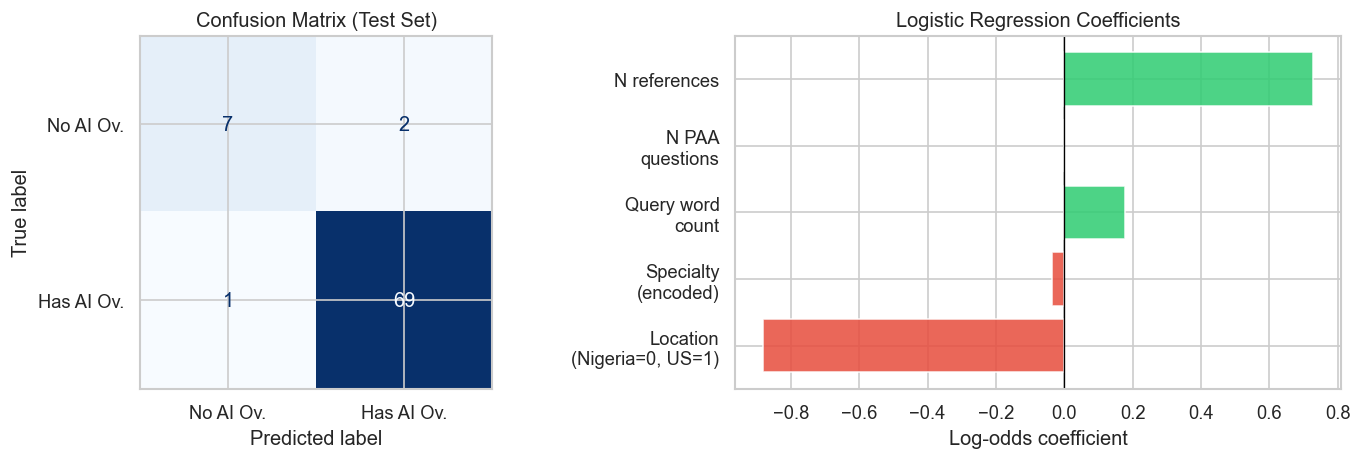

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No AI Ov.', 'Has AI Ov.'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Test Set)')

# Coefficients
feature_labels = [
    'Location\n(Nigeria=0, US=1)',
    'Specialty\n(encoded)',
    'Query word\ncount',
    'N PAA\nquestions',
    'N references',
]
coefs = model.coef_[0]
colors_coef = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs]
axes[1].barh(feature_labels, coefs, color=colors_coef, alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Log-odds coefficient')
axes[1].set_title('Logistic Regression Coefficients')

plt.tight_layout()
plt.show()

In [11]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(f'R²: {r2:.3f}')

R²: 0.624


### Interpretation

The logistic regression predicts whether Google returns an AI Overview for a given query. Key take-aways:

- A **positive coefficient** for a feature increases the log-odds of an AI Overview appearing.
- A **negative coefficient** decreases them.
- Given that ~90% of queries in both locations already trigger an AI Overview, most variation in the model will come from the minority of queries that do *not* trigger one.

Inspect the coefficients above to understand which features matter most (e.g., does location or number of references drive the prediction?).

In [12]:
from sklearn.model_selection import train_test_split
import pandas as pd
from catboost import CatBoostRegressor, CatBoostClassifier
import shap
import numpy as np

In [13]:
catboost_model = CatBoostRegressor(iterations=1000, learning_rate=0.1,
                                   depth=6, verbose=0)

# Train the model
catboost_model.fit(X_train, y_train,
                   eval_set=(X_test,y_test),
                   plot=False)

# Make predictions
y_pred = catboost_model.predict(X_test)

In [14]:
explainer = shap.Explainer(catboost_model, X_train)
shap_values = explainer(X_test)

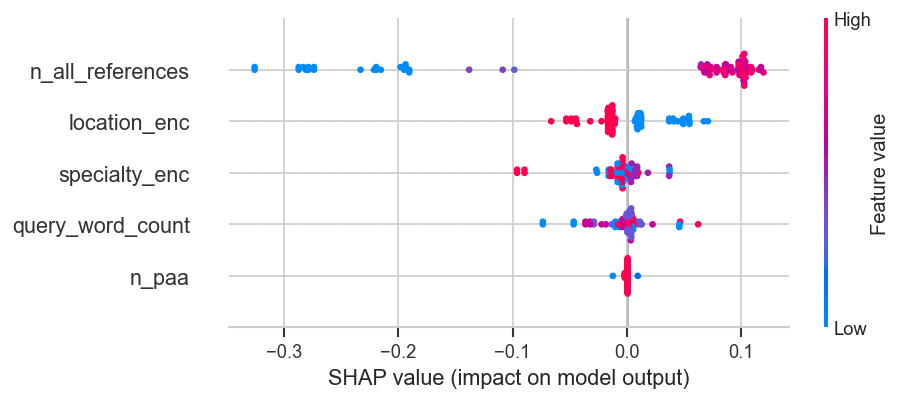

In [15]:
shap.summary_plot(shap_values, X_test, )

array([[1.       , 0.6508184],
       [0.6508184, 1.       ]])

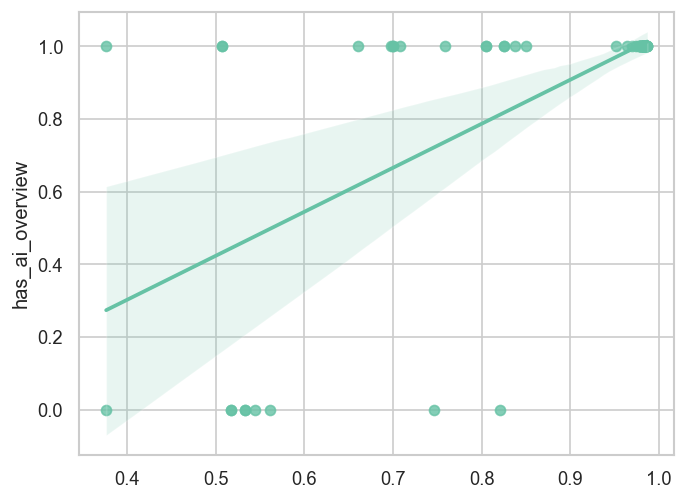

In [16]:
import seaborn as sns

sns.regplot(x = y_pred, y = y_test)

np.corrcoef(y_pred, y_test)